### Here we will perform the typical gp bayes opinf for the same system.

In [4]:
import importlib
import os
import h5py
import numpy as np

import opinf

import config
import utils
import step1_generate_data as step1
import step2_fitgps as step2
import step3_estimate as step3

importlib.reload(step1)
importlib.reload(step2)
importlib.reload(step3)

Logging to log.log


<module 'step3_estimate' from '/home/anthonypoole/repos/probabilistic_rom_inference/euler/step3_estimate.py'>

In [5]:
gp_regularizer: float = 1e-6
ndraws: int = 100
exportto: str = None
openonsave: bool = False
ddtdata: bool = False

training_span = (0, 0.08)
num_samples = 250
noiselevel = .15
num_regression_points = 400
numPODmodes = 6

normalization = 1e-5

if isinstance(numPODmodes, (list, tuple)) and len(numPODmodes) == 1:
    numPODmodes = numPODmodes[0]

# Report on experimental scenario.
utils.summarize_experiment(
    training_span=training_span,
    num_samples=num_samples,
    noiselevel=noiselevel,
    num_regression_points=num_regression_points,
    numPODmodes=numPODmodes,
    gp_regularizer=gp_regularizer,
    ndraws=ndraws,
)

# Step 1: Generate data ---------------------------------------------------
(
    model,
    time_domain,
    true_states,
    time_domain_sampled,
    snapshots_sampled,
) = step1.trajectory(training_span, num_samples, noiselevel)

time_domain_eval_training = np.linspace(0, max(time_domain_sampled), num_regression_points)
time_domain_eval_prediction = np.linspace(0, max(time_domain), int(num_regression_points/max(time_domain_sampled) * max(time_domain)))


EXPERIMENTAL SCENARIO
Data: 250 uniformly sampled snapshots over 0.00 ≤ t < 0.08 with 15.00% noise
Dimension: retaining 6 POD modes
Training: using 400 regression points
GP regularization: eta = 1.00e-06
Posterior: 100 draws

generating training data...done in 0.88 s.


In [6]:
# Step 2: Fit Gaussian processes to data ----------------------------------
# Dimensionality reduction (POD).
with opinf.utils.TimedBlock(
    f"reducing noisy training states to {numPODmodes} dimensions"
):
    basis = config.Basis(num_vectors=numPODmodes)
    basis.fit(snapshots_sampled)
    ax = basis.plot_svdval_decay()
    ax.set_xlim(right=20)
    ax.set_ylim(bottom=1e-4)
    utils.save_figure("svdvals.pdf", andopen=openonsave)
    snapshots_compressed = basis.compress(snapshots_sampled)
    true_states_compressed = basis.compress(true_states)
    if exportto is not None:
        os.makedirs(os.path.dirname(exportto), exist_ok=True)
        np.save(f"{exportto}-svdvals.npy", basis.svdvals)

# Fit Gaussian process kernels to the compressed training data.
time_domain_training = np.linspace(
    training_span[0],
    training_span[-1],
    num_regression_points,
)
gps = step2.fit_gaussian_processes(
    time_domain_training=time_domain_training,
    time_domain_sampled=time_domain_sampled,
    snapshots_sampled=snapshots_compressed,
    gp_regularizer=gp_regularizer,
)
q0 = snapshots_compressed[:, 0]

reducing noisy training states to 6 dimensions...(600, 250) (600, 250)
Saving /home/anthonypoole/repos/probabilistic_rom_inference/euler/figures/sep25/10-59-44/svdvals.pdf...done in 0.32 s.
done in 0.38 s.

fitting GP model for state 'r_01'...
Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 3.0793e-01
	\ell = 3.9952e-03
	\chi = 5.8094e-03
done in 90.52 s.
computing weight matrix...done in 0.19 s.

fitting GP model for state 'r_02'...
Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 3.0261e-01
	\ell = 3.8440e-03
	\chi = 5.0177e-03
done in 114.52 s.
computing weight matrix...done in 0.19 s.

fitting GP model for state 'r_03'...
Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 9.8324e-02
	\ell = 4.8724e-03
	\chi = 3.1383e-03
done in 21.01 s.
computing weight matrix...done in 0.15 s.

fitting GP model for sta

In [7]:
# Create the posterior and fit it 
input_func = config.ReducedOrderModel.input_func
inputs = None if input_func is None else input_func(time_domain_training)
bayesian_model = step3.estimate_posterior(
    time_domain=time_domain,
    gps=gps,
    inputs=inputs,
)

constructing posterior hyperparameters...

GRIDSEARCH
(1/81) Testing regularizer 1.0000e-16...UNSTABLE
(2/81) Testing regularizer 1.7783e-16...UNSTABLE
(3/81) Testing regularizer 3.1623e-16...UNSTABLE
(4/81) Testing regularizer 5.6234e-16...UNSTABLE
(5/81) Testing regularizer 1.0000e-15...UNSTABLE
(6/81) Testing regularizer 1.7783e-15...UNSTABLE
(7/81) Testing regularizer 3.1623e-15...UNSTABLE
(8/81) Testing regularizer 5.6234e-15...UNSTABLE
(9/81) Testing regularizer 1.0000e-14...UNSTABLE
(10/81) Testing regularizer 1.7783e-14...UNSTABLE
(11/81) Testing regularizer 3.1623e-14...UNSTABLE
(12/81) Testing regularizer 5.6234e-14...UNSTABLE
(13/81) Testing regularizer 1.0000e-13...UNSTABLE
(14/81) Testing regularizer 1.7783e-13...UNSTABLE
(15/81) Testing regularizer 3.1623e-13...UNSTABLE
(16/81) Testing regularizer 5.6234e-13...UNSTABLE
(17/81) Testing regularizer 1.0000e-12...UNSTABLE
(18/81) Testing regularizer 1.7783e-12...UNSTABLE
(19/81) Testing regularizer 3.1623e-12...UNSTABLE
(20/8

In [8]:
# Draw samples from the posterior.
with opinf.utils.TimedBlock("sampling posterior distribution"):
    draws_compressed_training = []
    draws_compressed = []
    qbar = snapshots_compressed.mean(axis=1).reshape((-1, 1))
    bound = 5 * np.max(np.abs(snapshots_compressed - qbar), axis=1)
    num_unstables = 0
    Os = []
    for _ in range(ndraws):
        draw = bayesian_model.predict(
            initial_conditions=q0,
            timepoints=time_domain,
            input_func=input_func,
        )
        training_draw = bayesian_model.predict(
            initial_conditions=q0,
            timepoints=time_domain_eval_training,
            input_func=input_func,
        )
        Os.append(bayesian_model.rvs())
        if draw.shape[1] != time_domain.size or training_draw.shape[1] != time_domain_training.size:
            num_unstables += 1
            continue
        if np.any(np.abs(draw - qbar).max(axis=1) > bound):
            num_unstables += 1
            continue
        draws_compressed_training.append(training_draw)
        draws_compressed.append(draw)
    if num_unstables:
        print(f"\n{num_unstables}/{ndraws} draws unstable")

    # Translate results back to original state space.
    draws = [basis.decompress(draw) for draw in draws_compressed]
    Os = np.array(Os)


sampling posterior distribution...done in 0.86 s.


(6, 1) (6, 1) (6, 1)
Number of samples: 1


<Figure size 640x480 with 0 Axes>

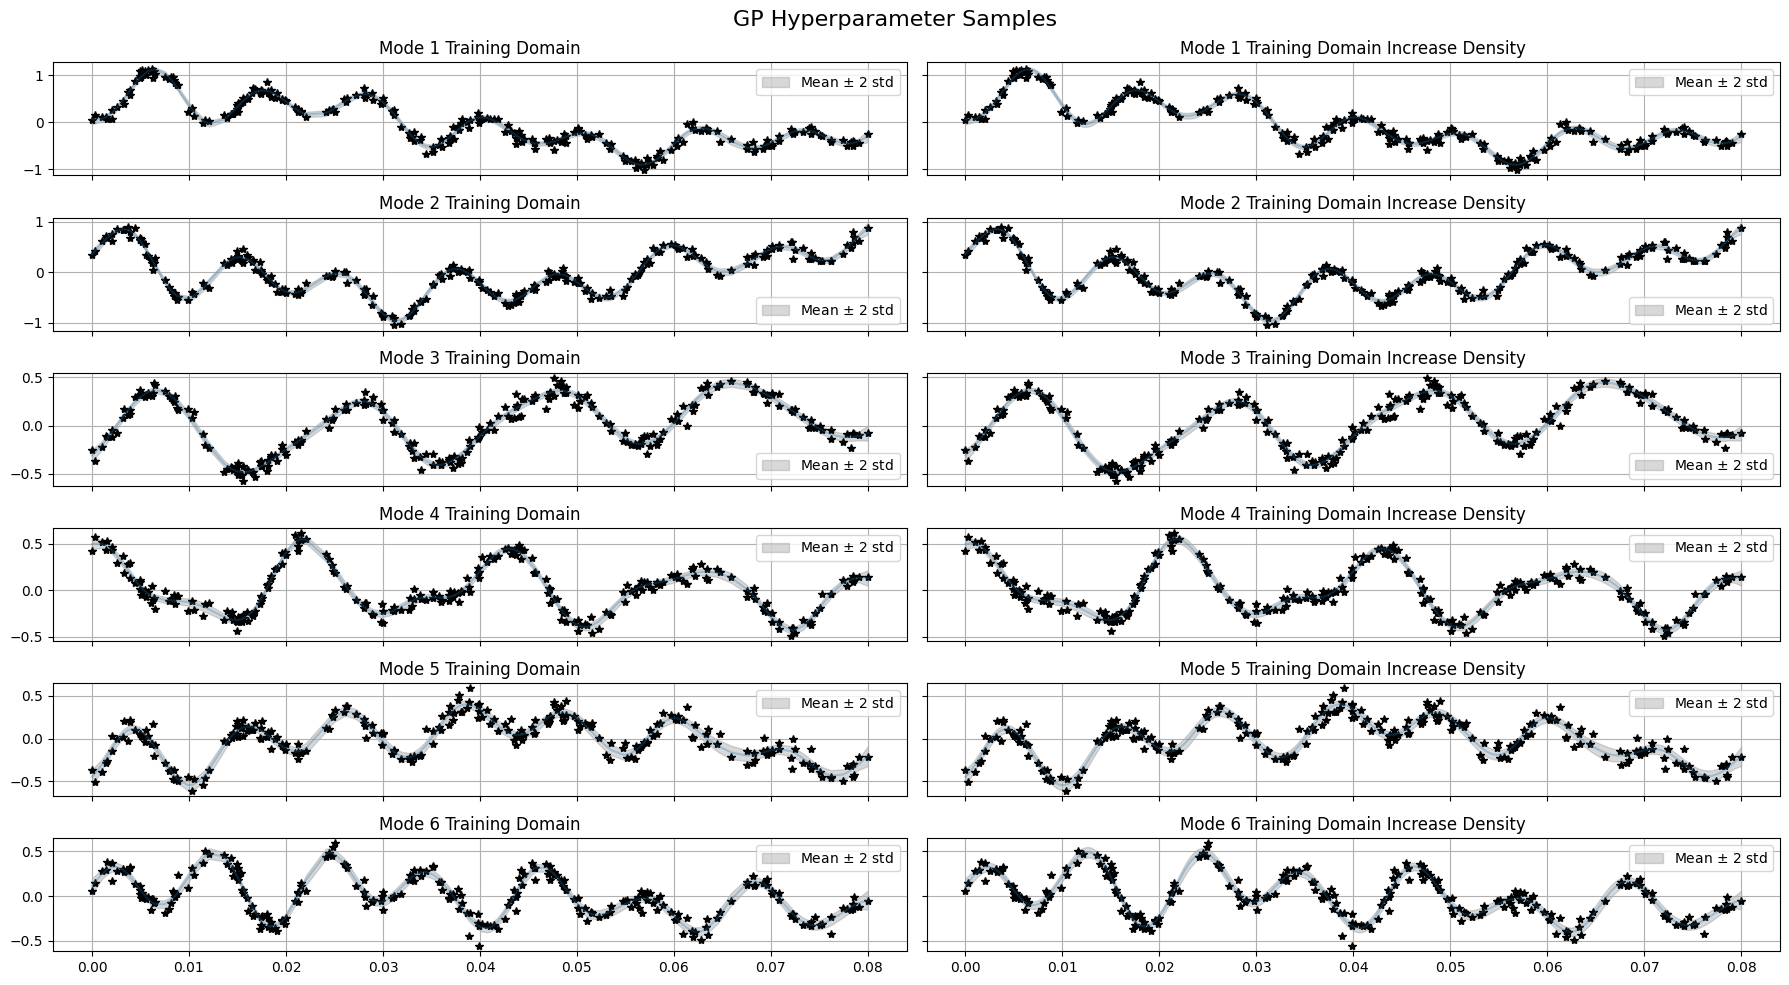

In [12]:
# Plot posterior samples
import euler_plotter
import importlib
importlib.reload(euler_plotter)

time_domain_eval_training = np.linspace(0, max(time_domain_sampled), num_regression_points)
time_domain_eval_prediction = np.linspace(0, max(time_domain), int(num_regression_points/max(time_domain_sampled) * max(time_domain)))

lengthscales = np.array([gps[i].gpr.kernel_.k1.k2.length_scale for i in range(numPODmodes)])[:, None]
variances = np.array([gps[i].gpr.kernel_.k1.k1.constant_value for i in range(numPODmodes)])[:, None]
noises = np.array([gps[i].gpr.kernel_.k2.noise_level for i in range(numPODmodes)])[:, None]

print(lengthscales.shape, variances.shape, noises.shape)

plotter = euler_plotter.EulerPlotter(
            numPODmodes=numPODmodes,
            time_domain_training=time_domain_sampled, 
            time_domain_prediction=time_domain, 
            time_domain_eval_training=time_domain_eval_training,
            time_domain_eval_prediction=time_domain_eval_prediction,
            snapshots_training=snapshots_compressed, 
            snapshots_prediction=true_states_compressed,
            )

plotter.gp_plot_state(
    lengthscales=lengthscales,
    variances=variances,
    noises=noises,
    max_num_samples=250,
    figsize=(18,10)
)


<Figure size 640x480 with 0 Axes>

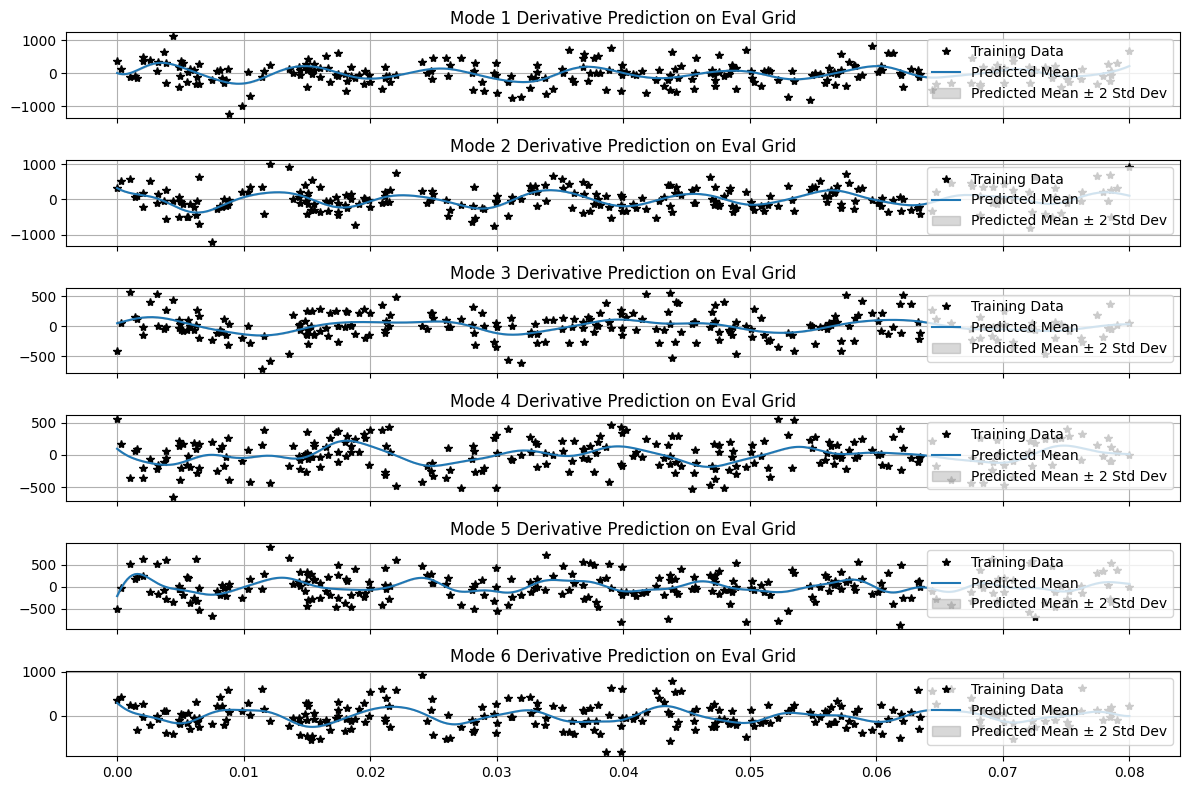

In [13]:

plotter.gp_plot_derivatives()

<Figure size 640x480 with 0 Axes>

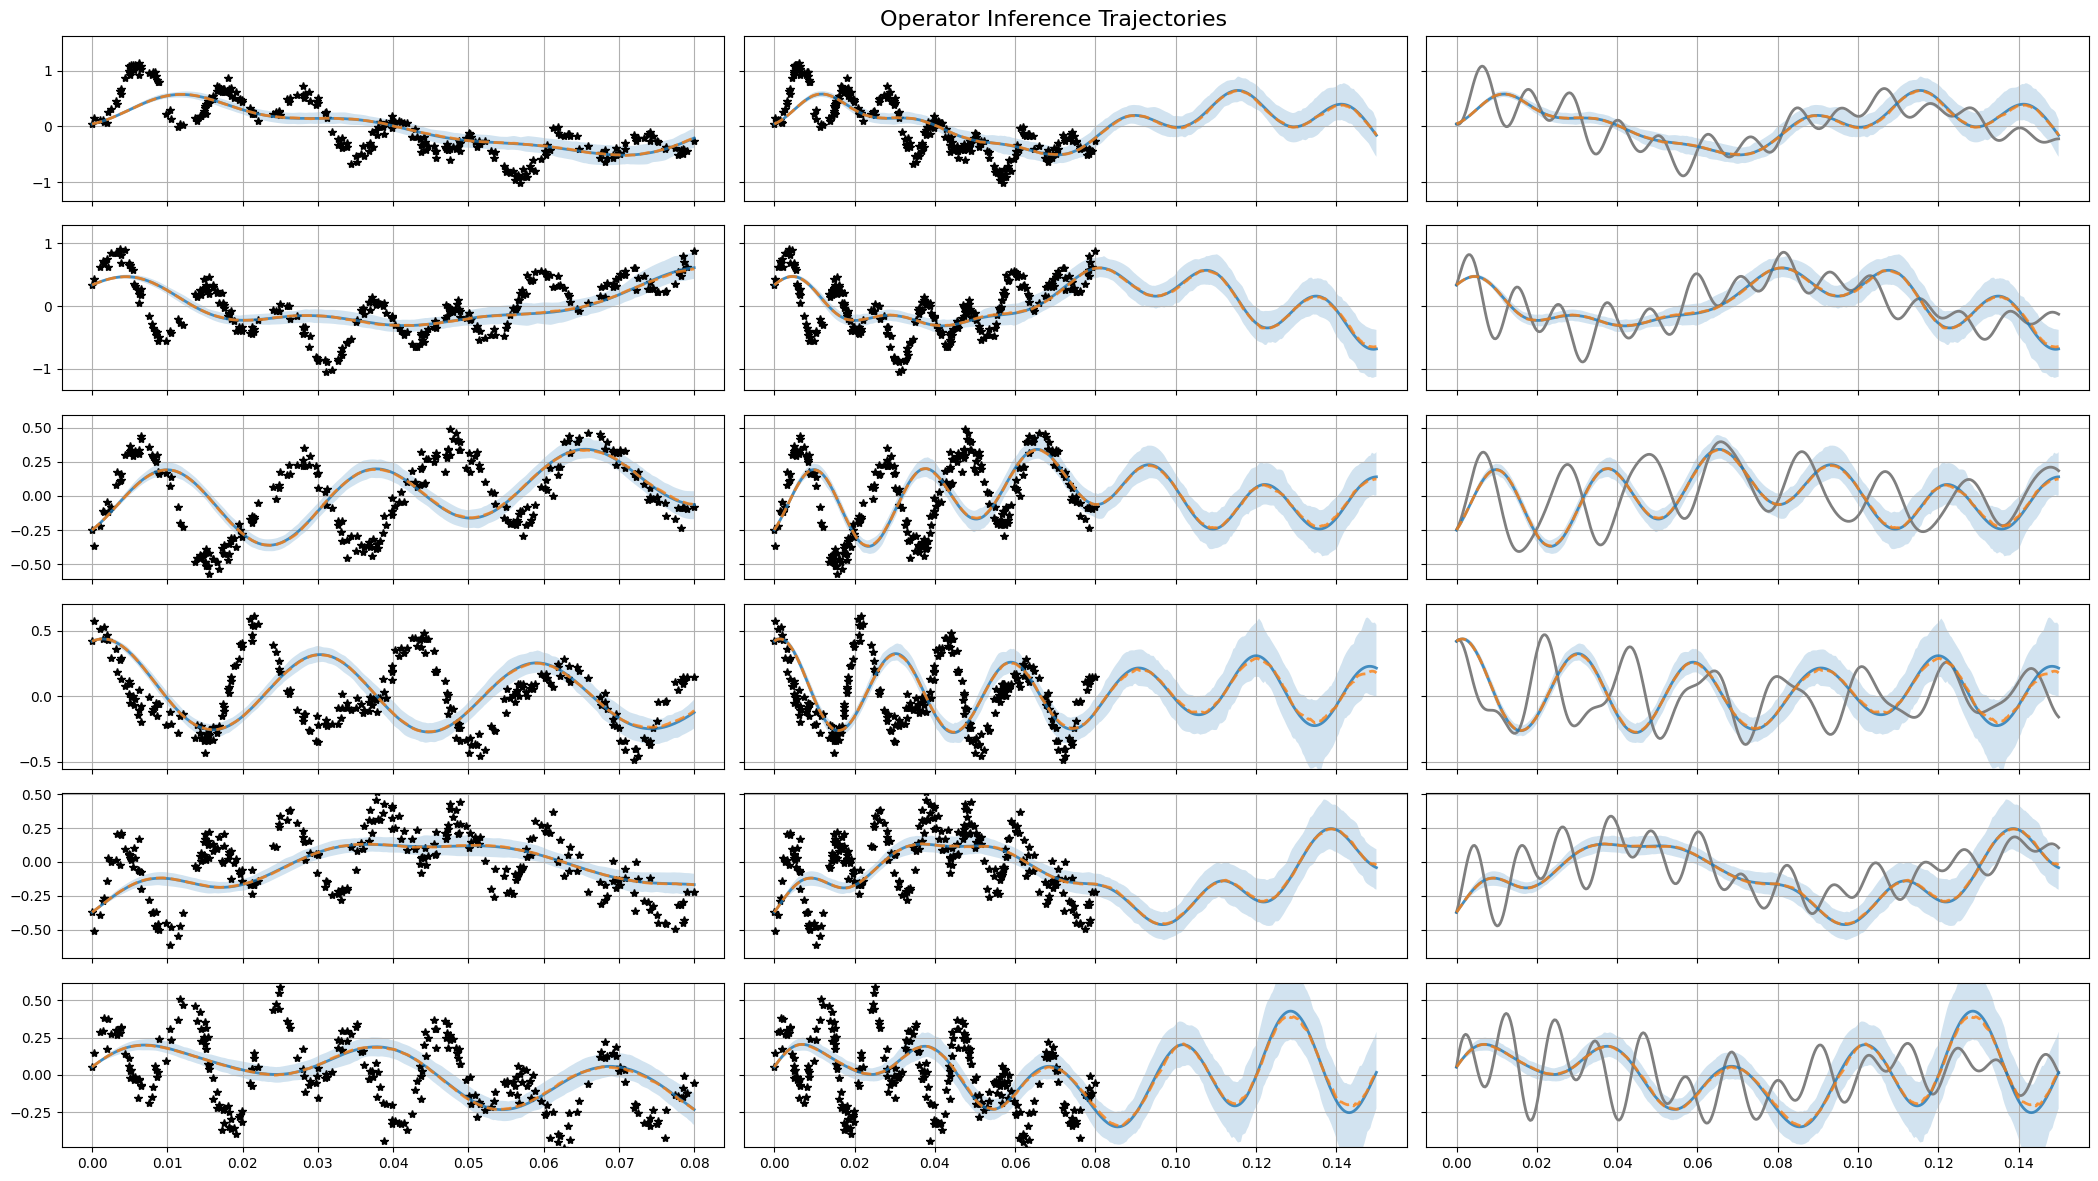

In [14]:
plotter.operator_plot_trajectories(
        draws_training = draws_compressed_training,
        draws_prediction = draws_compressed,
        time_domain_prediction = time_domain,
        figsize=(21, 12),)